# Subject-Level Transfer Learning — Alzheimer's MRI Classification
## AI4BioSig @ IEEE BIBM 2026
**Authors:** Haiyang Tang, Hemshankar Laugi (UTA Bioengineering)

### What this notebook does differently from your prior notebooks:
| Prior notebooks | This notebook |
|---|---|
| Slice-level 80/10/10 batch split | **Subject-level 5-fold CV** |
| Subject leakage across train/test | **Zero subject overlap guaranteed** |
| Slice-level accuracy reported | **Subject-level F1 + AUC reported** |
| TensorFlow/Keras | **PyTorch** (required for RadImageNet) |
| 4-class (Moderate=2 subjects) | **3-class** (Moderate collapsed into Mild) |

### Audit findings (from your Transfer_Learning_1.ipynb):
- 347 unique subjects | 86,437 slices
- Non Demented: 266 | Very Mild: 58 | Mild: 21 | **Moderate: 2** ← too few for 4-class CV
- Filename regex confirmed: `OAS1_XXXX_MR1_mpr-X_SLICE.jpg` (0 parse failures)
- No subject appears in >1 class ✓

### Class design:
- **0 — Non Demented** (266 subjects)
- **1 — Very Mild Dementia** (58 subjects)  
- **2 — Mild+Moderate Dementia** (21+2 = 23 subjects)

In [1]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────
# PyTorch is pre-installed on Colab GPU runtimes
# Run: Runtime → Change runtime type → T4 GPU

import os, re, zipfile, shutil, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
from google.colab import drive

warnings.filterwarnings('ignore')

print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('✓ Imports complete')

PyTorch 2.11.0+cu128
CUDA available: True
Device: cuda
✓ Imports complete


In [2]:
from collections import OrderedDict

def load_radimagenet_weights(model, path):
    """Load RadImageNet-ResNet50_notop weights into a torchvision ResNet-50."""
    raw = torch.load(path, map_location='cpu')

    stage_map = {
        'backbone.0.': 'conv1.',
        'backbone.1.': 'bn1.',
        'backbone.4.': 'layer1.',
        'backbone.5.': 'layer2.',
        'backbone.6.': 'layer3.',
        'backbone.7.': 'layer4.',
    }

    remapped = OrderedDict()
    for k, v in raw.items():
        new_k = None
        for old, new in stage_map.items():
            if k.startswith(old):
                new_k = new + k[len(old):]
                break
        if new_k is not None:
            remapped[new_k] = v

    missing, unexpected = model.load_state_dict(remapped, strict=False)

    backbone_keys = [k for k in model.state_dict() if not k.startswith('fc.')]
    coverage = (len(backbone_keys) - len([k for k in missing if not k.startswith('fc.')])) / len(backbone_keys)

    assert coverage >= 0.99, f"RadImageNet backbone coverage {coverage:.1%} — abort"
    print(f"  RadImageNet loaded: backbone coverage {coverage:.1%}, missing={missing}, unexpected={unexpected}")
    return model

In [3]:
# ── Cell 2: Mount Drive & Configuration ───────────────────────────────
drive.mount('/content/drive', force_remount=True)

# ── Paths (matches your existing setup) ──────────────────────────────
ZIP_PATH    = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
EXTRACT_DIR = '/content/Data'
DATA_DIR    = '/content/Data/AD Datasets/Data'
# RadImageNet weights (for Cell 11 — download from github.com/BMEII-AI/RadImageNet)
RAD_WEIGHTS = '/content/drive/MyDrive/Transfer Learning Project/Code/RadImageNet-ResNet50_notop_torch.pth'
OUTPUT_DIR  = '/content/drive/MyDrive/OASIS_AI4BioSig_Results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Imaging ───────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 128   # A100 has 80GB — larger batches train faster
NUM_WORKERS = 4     # more CPU cores available too
NUM_WORKERS = 2

# ── Training ──────────────────────────────────────────────────────────
EPOCHS      = 50
LR_HEAD     = 1e-4    # head learning rate
LR_BACKBONE = 1e-5    # backbone learning rate (for partial/full fine-tuning)
WEIGHT_DECAY= 1e-4
PATIENCE    = 10      # early stopping patience on val subject-F1
SEED        = 42

# ── Experiment design ─────────────────────────────────────────────────
N_FOLDS     = 5

# ── Class mapping: collapse Moderate (2 subjects) into Mild ──────────
# Moderate Dementia has only 2 subjects — impossible to evaluate reliably with 5-fold CV
CLASS_MAP = {
    'Non Demented':       0,
    'Very mild Dementia': 1,
    'Mild Dementia':      2,   # 21 subjects
    'Moderate Dementia':  2,   # 2 subjects → merged with Mild
}
CLASS_NAMES = ['Non Demented', 'Very Mild Dementia', 'Mild+Mod Dementia']
NUM_CLASSES = 3

torch.manual_seed(SEED)
np.random.seed(SEED)

print('✓ Configuration set')
print(f'NUM_CLASSES={NUM_CLASSES} | N_FOLDS={N_FOLDS} | BATCH={BATCH_SIZE} | DEVICE={DEVICE}')

Mounted at /content/drive
✓ Configuration set
NUM_CLASSES=3 | N_FOLDS=5 | BATCH=128 | DEVICE=cuda


In [4]:
# ── Cell 3: Extract ZIP & Build Manifest ──────────────────────────────
# (Same ZIP extraction as your existing notebooks)

if not os.path.isdir(DATA_DIR):
    print('Extracting dataset ZIP … (this takes ~2-3 min)')
    if os.path.exists(EXTRACT_DIR):
        shutil.rmtree(EXTRACT_DIR)
    os.makedirs(EXTRACT_DIR)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('✓ Extraction complete.')
else:
    print('Data already extracted — skipping.')

# ── Filename regex (confirmed in your audit: 0 failures on 86,437 files) ─
PATTERN = re.compile(
    r'^(OAS1_\d{4})_(MR\d+)_(mpr-\d+)_(\d+)\.(jpg|jpeg|png|bmp)$',
    re.IGNORECASE
)

records = []
for cls_folder, label in CLASS_MAP.items():
    cls_dir = os.path.join(DATA_DIR, cls_folder)
    if not os.path.isdir(cls_dir):
        print(f'⚠  Folder not found: {cls_dir}')
        continue
    for fname in os.listdir(cls_dir):
        m = PATTERN.match(fname)
        if m is None:
            continue
        records.append({
            'filepath':     os.path.join(cls_dir, fname),
            'filename':     fname,
            'class_folder': cls_folder,
            'label':        label,
            'subject_id':   m.group(1),
            'session':      m.group(2),
            'acquisition':  m.group(3),
            'slice_num':    int(m.group(4)),
        })

df = pd.DataFrame(records)
print(f'\n✓ Manifest: {len(df):,} images')

# ── Summary ───────────────────────────────────────────────────────────
print('\nClass distribution (after collapsing Moderate → Mild):')
summary = df.groupby('class_folder').agg(
    images=('filename','count'), subjects=('subject_id','nunique'),
    mapped_label=('label','first')
).sort_values('mapped_label')
print(summary)

# Subject-level table
subj_df = (
    df[['subject_id','label']]
    .drop_duplicates('subject_id')
    .sort_values('subject_id')
    .reset_index(drop=True)
)
print(f'\nTotal subjects: {len(subj_df)}')
print('Label distribution:', subj_df['label'].value_counts().sort_index().to_dict())

# Sanity check
cross = df.groupby('subject_id')['label'].nunique()
assert (cross > 1).sum() == 0, '❌ Subject in >1 class!'
print('✓ No cross-class subject contamination')

Extracting dataset ZIP … (this takes ~2-3 min)
✓ Extraction complete.

✓ Manifest: 86,437 images

Class distribution (after collapsing Moderate → Mild):
                    images  subjects  mapped_label
class_folder                                      
Non Demented         67222       266             0
Very mild Dementia   13725        58             1
Moderate Dementia      488         2             2
Mild Dementia         5002        21             2

Total subjects: 347
Label distribution: {0: 266, 1: 58, 2: 23}
✓ No cross-class subject contamination


In [5]:
# ── Cell 4: Subject-Level 5-Fold CV Splits ───────────────────────────
# StratifiedGroupKFold guarantees:
#   1) Each subject appears in exactly ONE fold's test set
#   2) Class ratios are approximately balanced across folds

subj_ids  = subj_df['subject_id'].values   # (347,)
subj_lbls = subj_df['label'].values        # (347,)
all_idx   = np.arange(len(subj_df))

# Outer 5-fold: each fold holds out ~20% of SUBJECTS as test
outer_sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_splits = []
for fold_i, (trainval_idx, test_idx) in enumerate(
        outer_sgkf.split(all_idx, subj_lbls, groups=subj_ids)):

    trainval_subj_df = subj_df.iloc[trainval_idx]
    trainval_lbls    = subj_lbls[trainval_idx]

    # Inner split: carve ~11% of trainval subjects into val (~10% of total)
    # Using StratifiedGroupKFold with 9 splits → take first split as val
    inner_sgkf = StratifiedGroupKFold(n_splits=9, shuffle=True, random_state=SEED)
    inner_train_idx, inner_val_idx = next(
        inner_sgkf.split(
            np.arange(len(trainval_subj_df)),
            trainval_lbls,
            groups=trainval_subj_df['subject_id'].values
        )
    )

    train_subjs = trainval_subj_df.iloc[inner_train_idx]['subject_id'].values
    val_subjs   = trainval_subj_df.iloc[inner_val_idx]['subject_id'].values
    test_subjs  = subj_df.iloc[test_idx]['subject_id'].values

    # ── Verify zero overlap ──────────────────────────────────────────
    assert len(set(train_subjs) & set(val_subjs))  == 0, 'Train/Val leak!'
    assert len(set(train_subjs) & set(test_subjs)) == 0, 'Train/Test leak!'
    assert len(set(val_subjs)   & set(test_subjs)) == 0, 'Val/Test leak!'

    fold_splits.append({
        'train': train_subjs.tolist(),
        'val':   val_subjs.tolist(),
        'test':  test_subjs.tolist(),
    })

    tr_dist = subj_df[subj_df['subject_id'].isin(train_subjs)]['label'].value_counts().sort_index()
    va_dist = subj_df[subj_df['subject_id'].isin(val_subjs)]['label'].value_counts().sort_index()
    te_dist = subj_df[subj_df['subject_id'].isin(test_subjs)]['label'].value_counts().sort_index()

    print(f'Fold {fold_i+1}: train={len(train_subjs)} {tr_dist.to_dict()} | '
          f'val={len(val_subjs)} {va_dist.to_dict()} | '
          f'test={len(test_subjs)} {te_dist.to_dict()}')

# Save splits for reproducibility
with open(f'{OUTPUT_DIR}/fold_splits.json', 'w') as f:
    json.dump(fold_splits, f, indent=2)
print(f'\n✓ Splits saved → {OUTPUT_DIR}/fold_splits.json')

Fold 1: train=247 {0: 189, 1: 42, 2: 16} | val=31 {0: 20, 1: 7, 2: 4} | test=69 {0: 57, 1: 9, 2: 3}
Fold 2: train=246 {0: 190, 1: 39, 2: 17} | val=31 {0: 24, 1: 5, 2: 2} | test=70 {0: 52, 1: 14, 2: 4}
Fold 3: train=246 {0: 191, 1: 43, 2: 12} | val=31 {0: 21, 1: 5, 2: 5} | test=70 {0: 54, 1: 10, 2: 6}
Fold 4: train=247 {0: 189, 1: 45, 2: 13} | val=31 {0: 23, 1: 4, 2: 4} | test=69 {0: 54, 1: 9, 2: 6}
Fold 5: train=247 {0: 192, 1: 39, 2: 16} | val=31 {0: 25, 1: 3, 2: 3} | test=69 {0: 49, 1: 16, 2: 4}

✓ Splits saved → /content/drive/MyDrive/OASIS_AI4BioSig_Results/fold_splits.json


In [6]:
# ── Cell 5: Dataset & DataLoader ─────────────────────────────────────

# ImageNet normalization (used for all conditions including scratch — standard practice)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class OASISDataset(Dataset):
    """Returns (image, label, subject_id) — subject_id needed for aggregation."""

    def __init__(self, manifest_df, subject_ids, transform=None):
        self.df = manifest_df[
            manifest_df['subject_id'].isin(subject_ids)
        ].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['label']), str(row['subject_id'])


def make_loaders(fold_dict, manifest_df, label_frac=1.0, seed=SEED):
    """Build train/val/test DataLoaders for one fold.
    label_frac: fraction of TRAINING SUBJECTS to use (for data-efficiency ablations).
    """
    rng = np.random.default_rng(seed)

    train_subjs = np.array(fold_dict['train'])
    val_subjs   = np.array(fold_dict['val'])
    test_subjs  = np.array(fold_dict['test'])

    # Stratified subject subsample for label fraction ablations
    if label_frac < 1.0:
        st = manifest_df[manifest_df['subject_id'].isin(train_subjs)] \
             .drop_duplicates('subject_id')[['subject_id','label']]
        keep = []
        for lbl in st['label'].unique():
            s = st[st['label']==lbl]['subject_id'].values
            k = max(1, int(len(s) * label_frac))
            keep.extend(rng.choice(s, k, replace=False).tolist())
        train_subjs = np.array(keep)

    train_ds = OASISDataset(manifest_df, train_subjs, train_transform)
    val_ds   = OASISDataset(manifest_df, val_subjs,   val_transform)
    test_ds  = OASISDataset(manifest_df, test_subjs,  val_transform)

    # Class-balanced loss weights from training labels
    train_labels = train_ds.df['label'].values
    cw = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

    kw = dict(num_workers=NUM_WORKERS, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)

    return train_loader, val_loader, test_loader, class_weights


print('✓ OASISDataset and make_loaders defined')
# Quick sanity check
sample_ds = OASISDataset(df, fold_splits[0]['train'][:5], val_transform)
img, lbl, sid = sample_ds[0]
print(f'Sample: image={img.shape}, label={lbl}, subject={sid}')

✓ OASISDataset and make_loaders defined
Sample: image=torch.Size([3, 224, 224]), label=0, subject=OAS1_0004


In [7]:
# ── Cell 6: Model Builder ─────────────────────────────────────────────

def build_model(init_strategy, fine_tune='full', num_classes=NUM_CLASSES):
    """
    Build ResNet-50 with specified initialization and fine-tuning strategy.

    init_strategy : 'scratch' | 'imagenet' | 'radimagenet'
    fine_tune     : 'full' | 'partial' | 'frozen'
                    NOTE: frozen/partial are forced to 'full' for scratch
                    (untrained frozen weights produce meaningless features)
    """
    if init_strategy == 'scratch':
        model = models.resnet50(weights=None)
        if fine_tune != 'full':
            print(f'  [scratch] fine_tune="{fine_tune}" forced to "full" (frozen scratch = meaningless)')
            fine_tune = 'full'

    elif init_strategy == 'imagenet':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    elif init_strategy == 'radimagenet':
        model = models.resnet50(weights=None)
        if not os.path.exists(RAD_WEIGHTS):
            raise FileNotFoundError(
                f'RadImageNet weights not found:\n  {RAD_WEIGHTS}\n'
                'Download from https://github.com/BMEII-AI/RadImageNet\n'
                'File: RadImageNet-ResNet50_notop_torch.pth'
            )
        # FIXED — uses the remapping function defined in Cell 3
        model = load_radimagenet_weights(model, RAD_WEIGHTS)
    else:
        raise ValueError(f'Unknown init_strategy: {init_strategy}')

    # ── Apply fine-tuning strategy ────────────────────────────────────
    if fine_tune == 'frozen':
        for p in model.parameters():
            p.requires_grad = False
    elif fine_tune == 'partial':
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer3.parameters():   # ResNet50 blocks 3+4
            p.requires_grad = True
        for p in model.layer4.parameters():
            p.requires_grad = True
    # 'full' → all parameters trainable (default ResNet state)

    # ── Replace classification head (always trainable) ────────────────
    in_features = model.fc.in_features   # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    for p in model.fc.parameters():
        p.requires_grad = True

    model = model.to(DEVICE)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'  [{init_strategy}/{fine_tune}] trainable params: {n_train:,} / {n_total:,}')

    return model, fine_tune   # return effective fine_tune (may have been overridden)


def build_optimizer(model, fine_tune):
    head_params     = list(model.fc.parameters())
    backbone_params = [p for n,p in model.named_parameters()
                       if 'fc' not in n and p.requires_grad]
    return torch.optim.AdamW(
        [{'params': head_params,     'lr': LR_HEAD},
         {'params': backbone_params, 'lr': LR_BACKBONE}],
        weight_decay=WEIGHT_DECAY
    )


print('✓ build_model and build_optimizer defined')
# Quick build test
m, _ = build_model('imagenet', 'frozen')
del m
torch.cuda.empty_cache()
print('✓ Model builder test passed')

✓ build_model and build_optimizer defined
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


  [imagenet/frozen] trainable params: 1,050,627 / 24,558,659
✓ Model builder test passed


In [8]:
# ── Cell 7: Training & Evaluation Functions ───────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for images, labels, _ in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    """
    Subject-level evaluation:
      1. Collect softmax prob vectors for ALL slices
      2. For each subject, take the MEAN probability vector (not majority vote)
         — mean preserves confidence information; enables proper AUC computation
      3. Compute subject-level F1, AUC, Accuracy
    """
    model.eval()
    all_probs, all_labels, all_subjs = [], [], []
    total_loss, n = 0.0, 0

    for images, labels, subj_ids in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss   = criterion(logits, labels)
        probs  = F.softmax(logits, dim=1).cpu().numpy()

        total_loss += loss.item() * len(labels)
        n          += len(labels)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_subjs.extend(list(subj_ids))

    all_probs  = np.array(all_probs)    # (N_slices, C)
    all_labels = np.array(all_labels)   # (N_slices,)
    all_subjs  = np.array(all_subjs)    # (N_slices,)

    # ── Subject-level aggregation (MEAN probability vector) ───────────
    unique_subjs = np.unique(all_subjs)
    subj_probs, subj_labels = [], []
    for sid in unique_subjs:
        mask = (all_subjs == sid)
        subj_probs.append(all_probs[mask].mean(axis=0))   # mean over slices
        subj_labels.append(int(all_labels[mask][0]))

    subj_probs  = np.array(subj_probs)  # (S, C)
    subj_preds  = subj_probs.argmax(axis=1)
    subj_labels = np.array(subj_labels)

    subj_f1  = f1_score(subj_labels, subj_preds, average='macro', zero_division=0)
    subj_acc = (subj_preds == subj_labels).mean()

    try:
        subj_auc = roc_auc_score(
            subj_labels, subj_probs,
            multi_class='ovr', average='macro'
        )
    except ValueError:
        subj_auc = float('nan')

    # Slice-level accuracy (for comparison to prior slice-level notebooks)
    slice_acc = (all_probs.argmax(axis=1) == all_labels).mean()

    return {
        'slice_loss':   total_loss / n,
        'slice_acc':    slice_acc,
        'subj_f1':      subj_f1,
        'subj_acc':     subj_acc,
        'subj_auc':     subj_auc,
        'subj_probs':   subj_probs,
        'subj_preds':   subj_preds,
        'subj_labels':  subj_labels,
    }


print('✓ train_epoch and evaluate defined')

✓ train_epoch and evaluate defined


In [9]:
# ── Cell 8: Run One Condition — with Resume Support ───────────────────
#
# Resume logic (checks Drive before training anything):
#   • Full condition CSV exists  → load instantly, skip all training
#   • Per-fold checkpoint exists → re-evaluate test set (~1 min), skip retraining
#   • Per-fold result CSV exists → load that fold's row, skip everything
#   • Nothing exists             → train from scratch as usual
#
# Safe to re-run Cell 9 after any interruption — won't redo completed work.

def run_condition(init_strategy, fine_tune, label_frac=1.0):

    # ── Fast path: entire condition already done ──────────────────────
    full_csv = f'{OUTPUT_DIR}/{init_strategy}_{fine_tune}_frac{label_frac}_results.csv'
    if os.path.exists(full_csv):
        print(f'  ✓ Condition {init_strategy}/{fine_tune} already complete — loading from cache')
        return pd.read_csv(full_csv)

    fold_results = []
    effective_ft = fine_tune  # updated per fold if build_model overrides it

    for fold_i, fold_dict in enumerate(fold_splits):
        fold_csv  = (f'{OUTPUT_DIR}/{init_strategy}_{fine_tune}'
                     f'_frac{label_frac}_fold{fold_i+1}_result.csv')
        ckpt_path = (f'{OUTPUT_DIR}/{init_strategy}_{fine_tune}'
                     f'_frac{label_frac}_fold{fold_i+1}.pth')

        # ── Case 1: per-fold result CSV already saved ─────────────────
        if os.path.exists(fold_csv):
            print(f'\n── Fold {fold_i+1}/{N_FOLDS} — result cached, skipping')
            fold_results.append(pd.read_csv(fold_csv).to_dict('records')[0])
            continue

        # ── Case 2: checkpoint exists, result CSV missing ─────────────
        #    Re-evaluate test set from saved weights (~1 min, no retraining)
        if os.path.exists(ckpt_path):
            print(f'\n── Fold {fold_i+1}/{N_FOLDS} — checkpoint found, re-evaluating …')
            train_ldr, val_ldr, test_ldr, class_wts = make_loaders(
                fold_dict, df, label_frac=label_frac, seed=SEED + fold_i)
            model, eff_ft = build_model(init_strategy, fine_tune)
            effective_ft  = eff_ft
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            criterion = nn.CrossEntropyLoss(weight=class_wts)
            test_m = evaluate(model, test_ldr, criterion)
            print(f'   TEST → subj_F1={test_m["subj_f1"]:.4f} '
                  f'subj_AUC={test_m["subj_auc"]:.4f} '
                  f'subj_Acc={test_m["subj_acc"]:.4f} '
                  f'[slice_Acc={test_m["slice_acc"]:.4f}]')
            row = {
                'init':             init_strategy,
                'fine_tune':        eff_ft,
                'label_frac':       label_frac,
                'fold':             fold_i + 1,
                'best_val_subj_f1': float('nan'),
                'test_subj_f1':     test_m['subj_f1'],
                'test_subj_auc':    test_m['subj_auc'],
                'test_subj_acc':    test_m['subj_acc'],
                'test_slice_acc':   test_m['slice_acc'],
            }
            fold_results.append(row)
            pd.DataFrame([row]).to_csv(fold_csv, index=False)
            del model
            torch.cuda.empty_cache()
            continue

        # ── Case 3: train from scratch ────────────────────────────────
        print(f'\n── Fold {fold_i+1}/{N_FOLDS} ─────────────────────────────────────')
        train_ldr, val_ldr, test_ldr, class_wts = make_loaders(
            fold_dict, df, label_frac=label_frac, seed=SEED + fold_i)
        print(f'   train slices: {len(train_ldr.dataset):,} | '
              f'val: {len(val_ldr.dataset):,} | test: {len(test_ldr.dataset):,}')

        model, effective_ft = build_model(init_strategy, fine_tune)
        criterion  = nn.CrossEntropyLoss(weight=class_wts)
        optimizer  = build_optimizer(model, effective_ft)
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=5)

        best_val_f1    = -1.0
        best_state     = None
        patience_count = 0

        for epoch in range(1, EPOCHS + 1):
            tr_loss, tr_acc = train_epoch(model, train_ldr, optimizer, criterion)
            val_m           = evaluate(model, val_ldr, criterion)
            val_f1          = val_m['subj_f1']
            scheduler.step(val_f1)

            if val_f1 > best_val_f1:
                best_val_f1    = val_f1
                best_state     = {k: v.clone() for k, v in model.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1

            if epoch % 5 == 0 or epoch == 1:
                print(f'   E{epoch:02d}: loss={tr_loss:.4f} tr_acc={tr_acc:.3f} '
                      f'val_F1={val_f1:.3f} val_AUC={val_m["subj_auc"]:.3f} '
                      f'best={best_val_f1:.3f} patience={patience_count}')

            if patience_count >= PATIENCE:
                print(f'   → Early stop at epoch {epoch} (best val_F1={best_val_f1:.4f})')
                break

        model.load_state_dict(best_state)
        test_m = evaluate(model, test_ldr, criterion)

        print(f'   TEST → subj_F1={test_m["subj_f1"]:.4f} '
              f'subj_AUC={test_m["subj_auc"]:.4f} '
              f'subj_Acc={test_m["subj_acc"]:.4f} '
              f'[slice_Acc={test_m["slice_acc"]:.4f}]')

        row = {
            'init':             init_strategy,
            'fine_tune':        effective_ft,
            'label_frac':       label_frac,
            'fold':             fold_i + 1,
            'best_val_subj_f1': best_val_f1,
            'test_subj_f1':     test_m['subj_f1'],
            'test_subj_auc':    test_m['subj_auc'],
            'test_subj_acc':    test_m['subj_acc'],
            'test_slice_acc':   test_m['slice_acc'],
        }
        fold_results.append(row)

        # Save per-fold result CSV (enables fold-level resume next time)
        pd.DataFrame([row]).to_csv(fold_csv, index=False)
        # Save checkpoint
        torch.save(best_state, ckpt_path)

        del model
        torch.cuda.empty_cache()

    result_df = pd.DataFrame(fold_results)
    result_df.to_csv(full_csv, index=False)
    return result_df


print('✓ run_condition() defined (with resume support)')

✓ run_condition() defined (with resume support)


In [ ]:
# ── Cell 9: Run Baseline Experiments ──────────────────────────────────
# 4 baseline conditions × 5 folds @ 100% label fraction
# Estimated runtime: 2-4 hours on T4 GPU
#
# Results save to Drive after EACH fold — safe to interrupt and resume
# If Colab disconnects, re-run from Cell 1-8 (fast), skip completed conditions below

BASELINE_CONDITIONS = [
    ('scratch',  'full'),      # No-pretraining baseline
    ('imagenet', 'frozen'),    # ImageNet, head-only
    ('imagenet', 'partial'),   # ImageNet, layer3+4+head unfrozen
    ('imagenet', 'full'),      # ImageNet, all layers
]

all_results = []

for init_strat, ft in BASELINE_CONDITIONS:
    print(f'\n{"="*65}')
    print(f'CONDITION: init={init_strat}  fine_tune={ft}  label_frac=100%')
    print('='*65)

    result_df = run_condition(init_strat, ft, label_frac=1.0)
    all_results.append(result_df)

    print(f'\n── {init_strat}/{ft} SUMMARY (5-fold mean ± std) ──')
    print(result_df[['test_subj_f1','test_subj_auc','test_subj_acc']]
          .agg(['mean','std']).round(4))

# Combine and save master results
baseline_df = pd.concat(all_results, ignore_index=True)
baseline_df.to_csv(f'{OUTPUT_DIR}/baseline_results.csv', index=False)
print(f'\n✓ All baseline results saved → {OUTPUT_DIR}/baseline_results.csv')


CONDITION: init=scratch  fine_tune=full  label_frac=100%
  ✓ Condition scratch/full already complete — loading from cache

── scratch/full SUMMARY (5-fold mean ± std) ──
      test_subj_f1  test_subj_auc  test_subj_acc
mean        0.5215         0.8482         0.7060
std         0.0973         0.0409         0.0663

CONDITION: init=imagenet  fine_tune=frozen  label_frac=100%

── Fold 1/5 — checkpoint found, re-evaluating …
  [imagenet/frozen] trainable params: 1,050,627 / 24,558,659
   TEST → subj_F1=0.5760 subj_AUC=0.9096 subj_Acc=0.8261 [slice_Acc=0.7680]

── Fold 2/5 — checkpoint found, re-evaluating …
  [imagenet/frozen] trainable params: 1,050,627 / 24,558,659
   TEST → subj_F1=0.5467 subj_AUC=0.8140 subj_Acc=0.7143 [slice_Acc=0.6606]

── Fold 3/5 ─────────────────────────────────────
   train slices: 62,098 | val: 7,442 | test: 16,897
  [imagenet/frozen] trainable params: 1,050,627 / 24,558,659
   E01: loss=0.8528 tr_acc=0.658 val_F1=0.537 val_AUC=0.755 best=0.537 patience=0
   


BASELINE RESULTS — Subject-Level 5-Fold CV
                    F1_mean  F1_std  AUC_mean  AUC_std  Acc_mean  SliceAcc
init     fine_tune                                                        
imagenet frozen      0.5462  0.0610    0.8566   0.0464    0.7318    0.6923
         full        0.5085  0.0895    0.8680   0.0466    0.7725    0.7523
         partial     0.5411  0.0953    0.8628   0.0432    0.7752    0.7462
scratch  full        0.5215  0.0973    0.8482   0.0409    0.7060    0.6659

LEAKAGE DEMONSTRATION
Your prior notebooks (slice-level split, 4-class):
  Without TL:        ~91%+ slice-level accuracy
  ImageNet (frozen): ~85-86% slice-level accuracy
  ImageNet (full):   ~92%+ slice-level accuracy

THIS notebook (subject-level split, 3-class):
  → Compare subject_acc above to see the true generalization gap
  → Slice_acc ≈ prior numbers; subj_acc < slice_acc = leakage confirmed


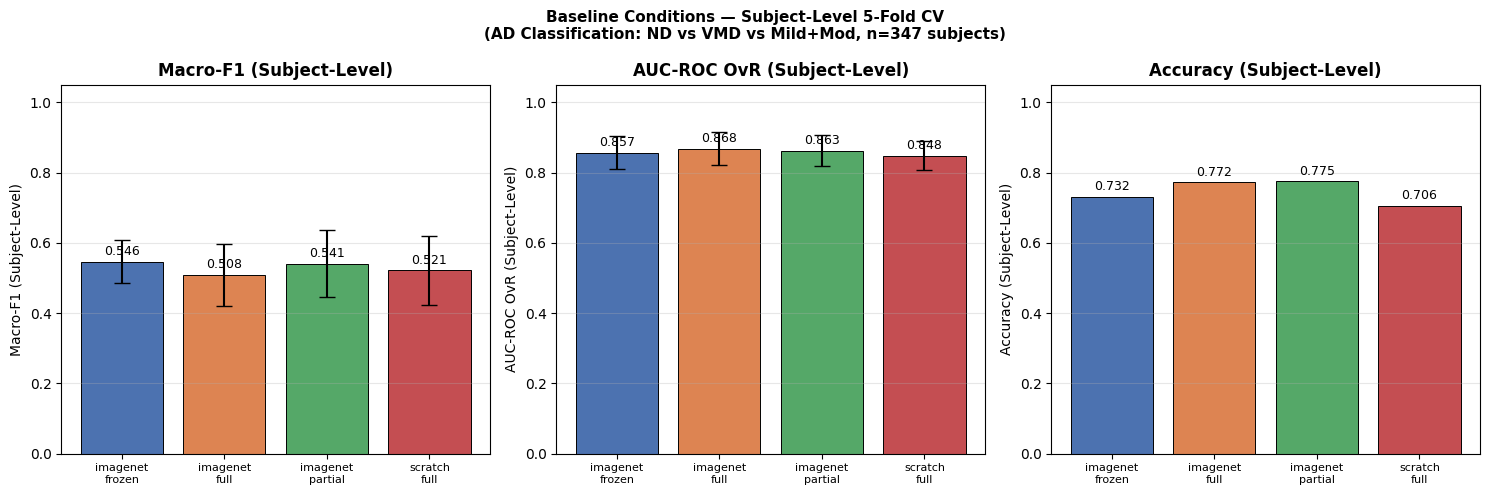

✓ Plot saved → /content/drive/MyDrive/OASIS_AI4BioSig_Results/baseline_comparison.png


In [ ]:
# ── Cell 10: Baseline Summary Table & Plots ───────────────────────────
# Run this after Cell 9 completes

# If resuming from saved CSV:
# baseline_df = pd.read_csv(f'{OUTPUT_DIR}/baseline_results.csv')

print('\n' + '='*65)
print('BASELINE RESULTS — Subject-Level 5-Fold CV')
print('='*65)

summary = (
    baseline_df
    .groupby(['init','fine_tune'])
    .agg(
        F1_mean    =('test_subj_f1',  'mean'),
        F1_std     =('test_subj_f1',  'std'),
        AUC_mean   =('test_subj_auc', 'mean'),
        AUC_std    =('test_subj_auc', 'std'),
        Acc_mean   =('test_subj_acc', 'mean'),
        SliceAcc   =('test_slice_acc','mean'),
    ).round(4)
)
print(summary.to_string())

print('\n' + '='*65)
print('LEAKAGE DEMONSTRATION')
print('='*65)
print('Your prior notebooks (slice-level split, 4-class):')
print('  Without TL:        ~91%+ slice-level accuracy')
print('  ImageNet (frozen): ~85-86% slice-level accuracy')
print('  ImageNet (full):   ~92%+ slice-level accuracy')
print()
print('THIS notebook (subject-level split, 3-class):')
print('  → Compare subject_acc above to see the true generalization gap')
print('  → Slice_acc ≈ prior numbers; subj_acc < slice_acc = leakage confirmed')

# ── Plot ──────────────────────────────────────────────────────────────
labels = [f"{r['init']}\n{r['fine_tune']}" for _, r in summary.reset_index().iterrows()]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('F1_mean',  'F1_std',  'Macro-F1 (Subject-Level)'),
    ('AUC_mean', 'AUC_std', 'AUC-ROC OvR (Subject-Level)'),
    ('Acc_mean', None,      'Accuracy (Subject-Level)'),
]

colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for ax, (mean_col, std_col, title) in zip(axes, pairs):
    vals = summary[mean_col].values
    errs = summary[std_col].values if std_col else None
    bars = ax.bar(labels, vals, yerr=errs, capsize=6,
                  color=colors[:len(vals)], edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Baseline Conditions — Subject-Level 5-Fold CV\n'
             '(AD Classification: ND vs VMD vs Mild+Mod, n=347 subjects)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Plot saved → {OUTPUT_DIR}/baseline_comparison.png')

In [ ]:
# Clear stale RadImageNet results so they retrain with correct weights
import glob

to_delete = (
    glob.glob(f'{OUTPUT_DIR}/radimagenet_*.csv') +
    glob.glob(f'{OUTPUT_DIR}/radimagenet_*_fold*_result.csv') +
    [f'{OUTPUT_DIR}/all_results_combined.csv']
)
for f in to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f'Deleted: {os.path.basename(f)}')
print('Cache cleared — ready to rerun Cell 11.')

Deleted: radimagenet_frozen_frac1.0_fold1_result.csv
Deleted: radimagenet_frozen_frac1.0_fold2_result.csv
Deleted: radimagenet_frozen_frac1.0_fold3_result.csv
Deleted: radimagenet_frozen_frac1.0_fold4_result.csv
Deleted: radimagenet_frozen_frac1.0_fold5_result.csv
Deleted: radimagenet_frozen_frac1.0_results.csv
Deleted: radimagenet_partial_frac1.0_fold1_result.csv
Cache cleared — ready to rerun Cell 11.


In [ ]:
# Delete RadImageNet MODEL CHECKPOINTS (not just CSVs) from broken run
import glob, os

checkpoint_patterns = [
    f'{OUTPUT_DIR}/radimagenet_frozen_frac1.0_fold*.pth',
    f'{OUTPUT_DIR}/radimagenet_partial_frac1.0_fold*.pth',
    f'{OUTPUT_DIR}/radimagenet_full_frac1.0_fold*.pth',
]

deleted = 0
for pattern in checkpoint_patterns:
    for f in glob.glob(pattern):
        os.remove(f)
        print(f'Deleted checkpoint: {os.path.basename(f)}')
        deleted += 1

# Also clear the RadImageNet CSVs again (in case they were re-saved)
for pattern in [f'{OUTPUT_DIR}/radimagenet_*.csv',
                f'{OUTPUT_DIR}/all_results_combined.csv']:
    for f in glob.glob(pattern):
        os.remove(f)
        print(f'Deleted CSV: {os.path.basename(f)}')

print(f'\nDone — {deleted} stale checkpoints removed. Ready to rerun Cell 11.')

Deleted checkpoint: radimagenet_frozen_frac1.0_fold1.pth
Deleted checkpoint: radimagenet_frozen_frac1.0_fold2.pth
Deleted checkpoint: radimagenet_frozen_frac1.0_fold3.pth
Deleted checkpoint: radimagenet_frozen_frac1.0_fold4.pth
Deleted checkpoint: radimagenet_frozen_frac1.0_fold5.pth
Deleted checkpoint: radimagenet_partial_frac1.0_fold1.pth

Done — 6 stale checkpoints removed. Ready to rerun Cell 11.


In [10]:
# ── Cell 11: RadImageNet Experiments ──────────────────────────────────
# Run AFTER downloading RadImageNet weights and completing Cell 9
#
# DOWNLOAD INSTRUCTIONS:
# 1. Go to https://github.com/BMEII-AI/RadImageNet
# 2. Download: RadImageNet-ResNet50_notop_torch.pth
# 3. Upload to Google Drive at:
#    Transfer Learning Project/Code/RadImageNet-ResNet50_notop_torch.pth

if not os.path.exists(RAD_WEIGHTS):
    print(f'⚠  RadImageNet weights not found at:\n   {RAD_WEIGHTS}')
    print('   Download from https://github.com/BMEII-AI/RadImageNet')
    print('   Skipping RadImageNet conditions.')
else:
    RAD_CONDITIONS = [
        ('radimagenet', 'frozen'),
        ('radimagenet', 'partial'),
        ('radimagenet', 'full'),
    ]

    rad_results = []
    for init_strat, ft in RAD_CONDITIONS:
        print(f'\n{"="*65}')
        print(f'CONDITION: init={init_strat}  fine_tune={ft}')
        print('='*65)
        result_df = run_condition(init_strat, ft, label_frac=1.0)
        rad_results.append(result_df)
        print(f'\n── {init_strat}/{ft} SUMMARY ──')
        print(result_df[['test_subj_f1','test_subj_auc']].agg(['mean','std']).round(4))

    rad_df = pd.concat(rad_results, ignore_index=True)
    rad_df.to_csv(f'{OUTPUT_DIR}/radimagenet_results.csv', index=False)
    print(f'\n✓ RadImageNet results saved → {OUTPUT_DIR}/radimagenet_results.csv')


CONDITION: init=radimagenet  fine_tune=frozen
  ✓ Condition radimagenet/frozen already complete — loading from cache

── radimagenet/frozen SUMMARY ──
      test_subj_f1  test_subj_auc
mean        0.5267         0.8620
std         0.0851         0.0261

CONDITION: init=radimagenet  fine_tune=partial

── Fold 1/5 ─────────────────────────────────────
   train slices: 61,976 | val: 7,686 | test: 16,775
  RadImageNet loaded: backbone coverage 100.0%, missing=['fc.weight', 'fc.bias'], unexpected=[]
  [radimagenet/partial] trainable params: 23,113,731 / 24,558,659
   E01: loss=0.8945 tr_acc=0.630 val_F1=0.553 val_AUC=0.827 best=0.553 patience=0
   E05: loss=0.6027 tr_acc=0.733 val_F1=0.585 val_AUC=0.847 best=0.585 patience=0
   E10: loss=0.4411 tr_acc=0.777 val_F1=0.530 val_AUC=0.859 best=0.585 patience=5
   E15: loss=0.3592 tr_acc=0.805 val_F1=0.637 val_AUC=0.860 best=0.637 patience=0
   E20: loss=0.3127 tr_acc=0.823 val_F1=0.592 val_AUC=0.858 best=0.637 patience=5
   E25: loss=0.2873 tr_

In [10]:
# ── Cell 12: Full Transfer Gain Analysis ─────────────────────────────
# Run after BOTH Cell 9 (baselines) and Cell 11 (RadImageNet) complete

# Load all results
baseline_df  = pd.read_csv(f'{OUTPUT_DIR}/baseline_results.csv')
rad_df       = pd.read_csv(f'{OUTPUT_DIR}/radimagenet_results.csv')
all_df       = pd.concat([baseline_df, rad_df], ignore_index=True)

metric = 'test_subj_f1'  # primary metric

# Mean over folds per condition
cond_means = (
    all_df.groupby(['init','fine_tune'])[metric]
    .agg(['mean','std'])
    .round(4)
)
print('\nAll conditions (5-fold mean ± std):')
print(cond_means)

# ── Transfer Gain vs Scratch ──────────────────────────────────────────
scratch_scores = all_df[all_df['init']=='scratch'][metric].values  # 5 fold scores
scratch_mean   = scratch_scores.mean()

print(f'\nScratch baseline (5-fold mean): {scratch_mean:.4f}')
print('\nTransfer Gain (ΔF1 = method − scratch):')

for (init, ft), grp in all_df[all_df['init']!='scratch'].groupby(['init','fine_tune']):
    gains = grp[metric].values - scratch_scores
    print(f'  {init}/{ft:8s}: Δ={gains.mean():+.4f} ± {gains.std():.4f}')

# ── Bootstrap paired test: ΔRad vs ΔImageNet ─────────────────────────
def bootstrap_paired(a, b, n_boot=10000, seed=42):
    """Test whether mean(a) != mean(b) with 10k bootstrap samples."""
    rng  = np.random.default_rng(seed)
    obs  = np.mean(a) - np.mean(b)
    diffs = []
    for _ in range(n_boot):
        idx  = rng.integers(0, len(a), size=len(a))
        diffs.append(a[idx].mean() - b[idx].mean())
    diffs = np.array(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    p_val = 2 * min((diffs >= obs).mean(), (diffs <= obs).mean())
    return obs, ci_lo, ci_hi, max(p_val, 1/n_boot)

print('\n── Bootstrap Test: Best RadImageNet vs Best ImageNet ──')
# Use best fine-tuning strategy for each pretraining domain
# Identify best conditions from cond_means
best_img_row = cond_means[cond_means.index.get_level_values('init')=='imagenet']['mean'].idxmax()
best_rad_row = cond_means[cond_means.index.get_level_values('init')=='radimagenet']['mean'].idxmax()

img_scores = all_df[(all_df['init']==best_img_row[0]) &
                    (all_df['fine_tune']==best_img_row[1])][metric].values
rad_scores = all_df[(all_df['init']==best_rad_row[0]) &
                    (all_df['fine_tune']==best_rad_row[1])][metric].values

obs, lo, hi, p = bootstrap_paired(rad_scores, img_scores)
print(f'  Best ImageNet ({best_img_row}): {img_scores.mean():.4f} ± {img_scores.std():.4f}')
print(f'  Best RadImageNet ({best_rad_row}): {rad_scores.mean():.4f} ± {rad_scores.std():.4f}')
print(f'  ΔRad−ΔImageNet = {obs:+.4f}  95% CI [{lo:.4f}, {hi:.4f}]  p={p:.4f}')
print(f'  → {"Significant" if p < 0.05 else "Not significant"} (α=0.05, Bonferroni pending)')

# Save full results
all_df.to_csv(f'{OUTPUT_DIR}/all_results_combined.csv', index=False)
print(f'\n✓ Combined results saved → {OUTPUT_DIR}/all_results_combined.csv')


All conditions (5-fold mean ± std):
                         mean     std
init        fine_tune                
imagenet    frozen     0.5462  0.0610
            full       0.5085  0.0895
            partial    0.5411  0.0953
radimagenet frozen     0.5267  0.0851
            full       0.5162  0.0894
            partial    0.5181  0.0720
scratch     full       0.5215  0.0973

Scratch baseline (5-fold mean): 0.5215

Transfer Gain (ΔF1 = method − scratch):
  imagenet/frozen  : Δ=+0.0247 ± 0.0577
  imagenet/full    : Δ=-0.0130 ± 0.1591
  imagenet/partial : Δ=+0.0196 ± 0.0839
  radimagenet/frozen  : Δ=+0.0052 ± 0.0350
  radimagenet/full    : Δ=-0.0053 ± 0.0965
  radimagenet/partial : Δ=-0.0034 ± 0.1021

── Bootstrap Test: Best RadImageNet vs Best ImageNet ──
  Best ImageNet (('imagenet', 'frozen')): 0.5462 ± 0.0546
  Best RadImageNet (('radimagenet', 'frozen')): 0.5267 ± 0.0761
  ΔRad−ΔImageNet = -0.0195  95% CI [-0.0747, 0.0313]  p=0.9740
  → Not significant (α=0.05, Bonferroni pending)


Rerunning best condition: imagenet/frozen (fold 1 only for demo)
  [imagenet/frozen] trainable params: 1,050,627 / 24,558,659

Test F1=0.5760 | AUC=0.9096

Classification Report (Subject-Level):
                    precision    recall  f1-score   support

      Non Demented     0.9286    0.9123    0.9204        57
Very Mild Dementia     0.5000    0.2222    0.3077         9
 Mild+Mod Dementia     0.3333    1.0000    0.5000         3

          accuracy                         0.8261        69
         macro avg     0.5873    0.7115    0.5760        69
      weighted avg     0.8468    0.8261    0.8222        69



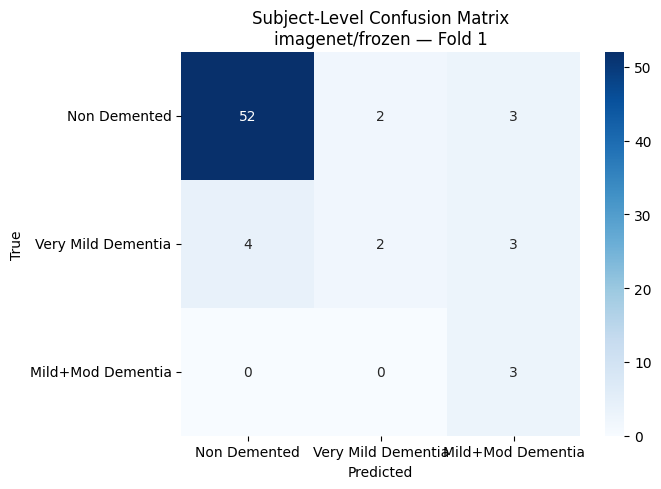

In [11]:
# ── Cell 13: Confusion Matrix & Per-Class Report (Best Condition) ─────
# Rerun best condition to get predictions for analysis
# Adjust these based on Cell 10 results:

BEST_INIT    = 'imagenet'   # ← UPDATE after seeing Cell 10 results
BEST_FT      = 'frozen'       # ← UPDATE after seeing Cell 10 results

print(f'Rerunning best condition: {BEST_INIT}/{BEST_FT} (fold 1 only for demo)')

model, eff_ft = build_model(BEST_INIT, BEST_FT)
ckpt_path = f'{OUTPUT_DIR}/{BEST_INIT}_{eff_ft}_frac1.0_fold1.pth'

if os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    train_ldr, val_ldr, test_ldr, class_wts = make_loaders(fold_splits[0], df)
    criterion = nn.CrossEntropyLoss(weight=class_wts)
    test_m = evaluate(model, test_ldr, criterion)

    print(f'\nTest F1={test_m["subj_f1"]:.4f} | AUC={test_m["subj_auc"]:.4f}')

    print('\nClassification Report (Subject-Level):')
    print(classification_report(
        test_m['subj_labels'], test_m['subj_preds'],
        target_names=CLASS_NAMES, digits=4
    ))

    # Confusion matrix
    cm = confusion_matrix(test_m['subj_labels'], test_m['subj_preds'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Subject-Level Confusion Matrix\n{BEST_INIT}/{BEST_FT} — Fold 1')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_best.png', dpi=150)
    plt.show()
else:
    print(f'Checkpoint not found: {ckpt_path}')
    print('Run Cell 9 first to generate checkpoints.')

del model
torch.cuda.empty_cache()

In [12]:
# Clear stale scratch_frozen ablation cache (naming was inconsistent — now using scratch/full)
import glob, os

stale = (
    glob.glob(f'{OUTPUT_DIR}/scratch_frozen_frac*.csv') +
    glob.glob(f'{OUTPUT_DIR}/scratch_frozen_frac*.pth') +
    [f'{OUTPUT_DIR}/ablation_results.csv']
)
for f in stale:
    if os.path.exists(f):
        os.remove(f)
        print(f'Deleted: {os.path.basename(f)}')
print('Ablation cache cleared.')
# NOTE: scratch_full_frac1.0 and imagenet_frozen_frac* CSVs are kept — still valid

Deleted: scratch_frozen_frac0.25_fold1_result.csv
Deleted: scratch_frozen_frac0.25_fold2_result.csv
Deleted: scratch_frozen_frac0.25_fold3_result.csv
Deleted: scratch_frozen_frac0.25_fold4_result.csv
Deleted: scratch_frozen_frac0.25_fold5_result.csv
Deleted: scratch_frozen_frac0.25_results.csv
Deleted: scratch_frozen_frac0.5_fold1_result.csv
Deleted: scratch_frozen_frac0.5_fold2_result.csv
Deleted: scratch_frozen_frac0.5_fold3_result.csv
Deleted: scratch_frozen_frac0.5_fold4_result.csv
Deleted: scratch_frozen_frac0.5_fold5_result.csv
Deleted: scratch_frozen_frac0.5_results.csv
Deleted: scratch_frozen_frac1.0_fold1_result.csv
Deleted: scratch_frozen_frac1.0_fold2_result.csv
Deleted: scratch_frozen_frac1.0_fold3_result.csv
Deleted: scratch_frozen_frac1.0_fold4_result.csv
Deleted: scratch_frozen_frac1.0_fold5_result.csv
Deleted: scratch_frozen_frac1.0_results.csv
Deleted: scratch_frozen_frac0.25_fold1.pth
Deleted: scratch_frozen_frac0.25_fold2.pth
Deleted: scratch_frozen_frac0.25_fold3.pt


ABLATION: scratch/full @ label_frac=0.25
  ✓ Condition scratch/full already complete — loading from cache

ABLATION: scratch/full @ label_frac=0.5

── Fold 1/5 ─────────────────────────────────────
   train slices: 30,988 | val: 7,686 | test: 16,775
  [scratch/full] trainable params: 24,558,659 / 24,558,659
   E01: loss=1.1047 tr_acc=0.405 val_F1=0.333 val_AUC=0.468 best=0.333 patience=0
   E05: loss=0.7315 tr_acc=0.667 val_F1=0.478 val_AUC=0.779 best=0.478 patience=0
   E10: loss=0.5992 tr_acc=0.714 val_F1=0.479 val_AUC=0.796 best=0.577 patience=4
   E15: loss=0.5071 tr_acc=0.753 val_F1=0.422 val_AUC=0.789 best=0.577 patience=9
   → Early stop at epoch 16 (best val_F1=0.5770)
   TEST → subj_F1=0.4235 subj_AUC=0.7965 subj_Acc=0.7536 [slice_Acc=0.6813]

── Fold 2/5 ─────────────────────────────────────
   train slices: 30,378 | val: 7,198 | test: 17,202
  [scratch/full] trainable params: 24,558,659 / 24,558,659
   E01: loss=1.1035 tr_acc=0.414 val_F1=0.407 val_AUC=0.687 best=0.407 pati

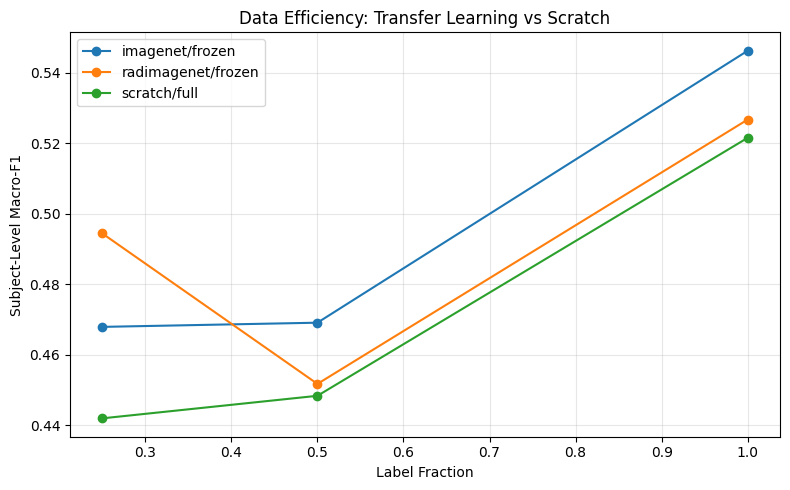

✓ Ablation plot saved → /content/drive/MyDrive/OASIS_AI4BioSig_Results/label_fraction_ablation.png


In [13]:
# ── Cell 14: Label Fraction Ablations (25% / 50% / 100%) ──────────────
# Update these AFTER running Cell 12 with corrected RadImageNet results:
BEST_IMAGENET_FT    = 'frozen'    # ← update from Cell 12 output
BEST_RADIMAGENET_FT = 'frozen'    # ← update from Cell 12 output (once corrected)

ABLATION_CONDITIONS = [
    ('scratch',     'full'),                    # was 'frozen' — now correct
    ('imagenet',    BEST_IMAGENET_FT),
    ('radimagenet', BEST_RADIMAGENET_FT),       # was commented out
]

LABEL_FRACS = [0.25, 0.5, 1.0]

ablation_results = []

for init_strat, ft in ABLATION_CONDITIONS:
    for frac in LABEL_FRACS:
        if frac == 1.0 and init_strat != 'radimagenet':
            # Already ran in Cell 9 — load from CSV instead of re-running
            csv_path = f'{OUTPUT_DIR}/{init_strat}_{ft}_frac1.0_results.csv'
            if os.path.exists(csv_path):
                ablation_results.append(pd.read_csv(csv_path))
                print(f'Loaded from cache: {init_strat}/{ft} @ {frac}')
                continue

        print(f'\n{"="*55}')
        print(f'ABLATION: {init_strat}/{ft} @ label_frac={frac}')
        print('='*55)
        result_df = run_condition(init_strat, ft, label_frac=frac)
        ablation_results.append(result_df)

ablation_df = pd.concat(ablation_results, ignore_index=True)
ablation_df.to_csv(f'{OUTPUT_DIR}/ablation_results.csv', index=False)

# ── Plot: Transfer Gain vs Label Fraction ────────────────────────────
pivot = (
    ablation_df
    .groupby(['init','fine_tune','label_frac'])['test_subj_f1']
    .mean()
    .unstack('label_frac')
)
print('\nF1 by condition and label fraction:')
print(pivot.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
for (init, ft), row in pivot.iterrows():
    ax.plot(row.index, row.values, marker='o', label=f'{init}/{ft}')
ax.set_xlabel('Label Fraction')
ax.set_ylabel('Subject-Level Macro-F1')
ax.set_title('Data Efficiency: Transfer Learning vs Scratch')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/label_fraction_ablation.png', dpi=150)
plt.show()
print(f'✓ Ablation plot saved → {OUTPUT_DIR}/label_fraction_ablation.png')

In [ ]:
# ============================================================
# RADIMAGENET CHECKPOINT DIAGNOSTIC
# Does the checkpoint actually match torchvision ResNet-50?
# ============================================================

import torch
import torchvision
from collections import OrderedDict

state = torch.load(RAD_WEIGHTS, map_location="cpu")

print("=" * 75)
print("1. RAW CHECKPOINT")
print("=" * 75)

print("Object type:", type(state))

if isinstance(state, dict):
    print("Number of top-level entries:", len(state))
    print("\nFirst 20 top-level keys:")
    for k in list(state.keys())[:20]:
        print(" ", k)

# ------------------------------------------------------------
# Check whether checkpoint is wrapped
# ------------------------------------------------------------

possible_wrappers = [
    "state_dict",
    "model_state_dict",
    "model",
    "net",
    "network",
    "weights"
]

unwrapped = state

if isinstance(state, dict):
    for key in possible_wrappers:
        if key in state and isinstance(state[key], dict):
            print(f"\nDetected possible wrapper: '{key}'")
            unwrapped = state[key]
            break

print("\n" + "=" * 75)
print("2. CHECKPOINT PARAMETER KEYS")
print("=" * 75)

print("Number of parameter entries:", len(unwrapped))

print("\nFirst 30 checkpoint keys:")
for k in list(unwrapped.keys())[:30]:
    value = unwrapped[k]

    if hasattr(value, "shape"):
        print(f"{k:60s} {tuple(value.shape)}")
    else:
        print(k)

# ------------------------------------------------------------
# torchvision ResNet-50
# ------------------------------------------------------------

model = torchvision.models.resnet50(weights=None)
model_state = model.state_dict()

print("\n" + "=" * 75)
print("3. TORCHVISION RESNET-50 KEYS")
print("=" * 75)

print("Number of model entries:", len(model_state))

print("\nFirst 30 model keys:")
for k in list(model_state.keys())[:30]:
    print(f"{k:60s} {tuple(model_state[k].shape)}")

# ------------------------------------------------------------
# Exact key overlap
# ------------------------------------------------------------

ckpt_keys = set(unwrapped.keys())
model_keys = set(model_state.keys())

exact_overlap = ckpt_keys & model_keys

print("\n" + "=" * 75)
print("4. EXACT KEY OVERLAP")
print("=" * 75)

print("Checkpoint keys:", len(ckpt_keys))
print("Model keys:     ", len(model_keys))
print("Exact matches:  ", len(exact_overlap))

print(
    f"Model-key coverage: "
    f"{100 * len(exact_overlap) / len(model_keys):.2f}%"
)

# ------------------------------------------------------------
# Shape-compatible exact matches
# ------------------------------------------------------------

shape_matches = []

for k in exact_overlap:
    try:
        if tuple(unwrapped[k].shape) == tuple(model_state[k].shape):
            shape_matches.append(k)
    except Exception:
        pass

print("\nShape-compatible exact matches:", len(shape_matches))

print(
    f"Shape-compatible coverage: "
    f"{100 * len(shape_matches) / len(model_keys):.2f}%"
)

# ------------------------------------------------------------
# Missing / unexpected examples
# ------------------------------------------------------------

missing = sorted(model_keys - ckpt_keys)
unexpected = sorted(ckpt_keys - model_keys)

print("\n" + "=" * 75)
print("5. MISMATCH EXAMPLES")
print("=" * 75)

print("\nFirst 30 MODEL keys missing from checkpoint:")
for k in missing[:30]:
    print(" ", k)

print("\nFirst 30 CHECKPOINT keys not expected by torchvision:")
for k in unexpected[:30]:
    print(" ", k)

# ------------------------------------------------------------
# Look for common prefixes
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("6. PREFIX DIAGNOSTIC")
print("=" * 75)

prefixes = [
    "module.",
    "model.",
    "net.",
    "network.",
    "backbone.",
    "encoder."
]

for prefix in prefixes:

    stripped = {}

    for k, v in unwrapped.items():
        new_k = k[len(prefix):] if k.startswith(prefix) else k
        stripped[new_k] = v

    overlap = set(stripped.keys()) & model_keys

    shape_ok = 0

    for k in overlap:
        try:
            if tuple(stripped[k].shape) == tuple(model_state[k].shape):
                shape_ok += 1
        except Exception:
            pass

    print(
        f"{prefix:12s} -> "
        f"exact overlap={len(overlap):3d}, "
        f"shape-compatible={shape_ok:3d}"
    )

1. RAW CHECKPOINT
Object type: <class 'collections.OrderedDict'>
Number of top-level entries: 318

First 20 top-level keys:
  backbone.0.weight
  backbone.1.weight
  backbone.1.bias
  backbone.1.running_mean
  backbone.1.running_var
  backbone.1.num_batches_tracked
  backbone.4.0.conv1.weight
  backbone.4.0.bn1.weight
  backbone.4.0.bn1.bias
  backbone.4.0.bn1.running_mean
  backbone.4.0.bn1.running_var
  backbone.4.0.bn1.num_batches_tracked
  backbone.4.0.conv2.weight
  backbone.4.0.bn2.weight
  backbone.4.0.bn2.bias
  backbone.4.0.bn2.running_mean
  backbone.4.0.bn2.running_var
  backbone.4.0.bn2.num_batches_tracked
  backbone.4.0.conv3.weight
  backbone.4.0.bn3.weight

2. CHECKPOINT PARAMETER KEYS
Number of parameter entries: 318

First 30 checkpoint keys:
backbone.0.weight                                            (64, 3, 7, 7)
backbone.1.weight                                            (64,)
backbone.1.bias                                              (64,)
backbone.1.running_me

In [ ]:
# ============================================================
# RADIMAGENET -> TORCHVISION RESNET-50 KEY REMAPPING DIAGNOSTIC
# No training. No files modified.
# ============================================================

import torch
import torchvision
from collections import OrderedDict

state = torch.load(RAD_WEIGHTS, map_location="cpu")

# ------------------------------------------------------------
# 1. Unwrap checkpoint if necessary
# ------------------------------------------------------------

possible_wrappers = [
    "state_dict",
    "model_state_dict",
    "model",
    "net",
    "network",
    "weights"
]

rad_state = state

if isinstance(state, dict):
    for wrapper in possible_wrappers:
        if wrapper in state and isinstance(state[wrapper], dict):
            print(f"Detected wrapper: {wrapper}")
            rad_state = state[wrapper]
            break

# ------------------------------------------------------------
# 2. Mapping function
#
# RadImageNet backbone appears to use:
#
# backbone.0 -> conv1
# backbone.1 -> bn1
# backbone.4 -> layer1
# backbone.5 -> layer2
# backbone.6 -> layer3
# backbone.7 -> layer4
#
# backbone.2 = ReLU      (no parameters)
# backbone.3 = MaxPool   (no parameters)
# ------------------------------------------------------------

def map_radimagenet_key(key):

    # Initial convolution
    if key.startswith("backbone.0."):
        return key.replace(
            "backbone.0.",
            "conv1.",
            1
        )

    # Initial batch norm
    if key.startswith("backbone.1."):
        return key.replace(
            "backbone.1.",
            "bn1.",
            1
        )

    # ResNet stages
    stage_map = {
        "backbone.4.": "layer1.",
        "backbone.5.": "layer2.",
        "backbone.6.": "layer3.",
        "backbone.7.": "layer4."
    }

    for old_prefix, new_prefix in stage_map.items():
        if key.startswith(old_prefix):
            return key.replace(
                old_prefix,
                new_prefix,
                1
            )

    return None


# ------------------------------------------------------------
# 3. Remap checkpoint
# ------------------------------------------------------------

remapped = OrderedDict()
unmapped_keys = []

for old_key, value in rad_state.items():

    new_key = map_radimagenet_key(old_key)

    if new_key is None:
        unmapped_keys.append(old_key)
    else:
        remapped[new_key] = value


# ------------------------------------------------------------
# 4. Compare against torchvision ResNet-50
# ------------------------------------------------------------

model = torchvision.models.resnet50(weights=None)
model_state = model.state_dict()

model_keys = set(model_state.keys())
remapped_keys = set(remapped.keys())

exact_overlap = remapped_keys & model_keys

shape_matches = []
shape_mismatches = []

for key in exact_overlap:

    checkpoint_shape = tuple(remapped[key].shape)
    model_shape = tuple(model_state[key].shape)

    if checkpoint_shape == model_shape:
        shape_matches.append(key)
    else:
        shape_mismatches.append(
            (
                key,
                checkpoint_shape,
                model_shape
            )
        )


# ------------------------------------------------------------
# 5. Print diagnostic
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RADIMAGENET REMAPPING RESULTS")
print("=" * 75)

print(f"Original checkpoint entries: {len(rad_state)}")
print(f"Successfully remapped:       {len(remapped)}")
print(f"Unmapped checkpoint keys:    {len(unmapped_keys)}")

print(f"\nTorchvision model entries:   {len(model_state)}")
print(f"Exact key matches:           {len(exact_overlap)}")
print(f"Shape-compatible matches:    {len(shape_matches)}")
print(f"Shape mismatches:            {len(shape_mismatches)}")

coverage = 100 * len(shape_matches) / len(model_state)

print(
    f"\nShape-compatible model coverage: "
    f"{coverage:.2f}%"
)


# ------------------------------------------------------------
# 6. Missing torchvision keys
# ------------------------------------------------------------

missing_model_keys = sorted(
    model_keys - set(shape_matches)
)

print("\n" + "=" * 75)
print("MODEL KEYS NOT PROVIDED BY RADIMAGENET")
print("=" * 75)

for key in missing_model_keys:
    print(" ", key)


# ------------------------------------------------------------
# 7. Unmapped RadImageNet keys
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("UNMAPPED RADIMAGENET KEYS")
print("=" * 75)

if len(unmapped_keys) == 0:
    print("None")
else:
    for key in unmapped_keys[:50]:
        print(" ", key)


# ------------------------------------------------------------
# 8. Shape mismatches
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SHAPE MISMATCHES")
print("=" * 75)

if len(shape_mismatches) == 0:
    print("None")
else:
    for item in shape_mismatches[:50]:
        print(item)


# ------------------------------------------------------------
# 9. Example translations
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXAMPLE KEY TRANSLATIONS")
print("=" * 75)

for old_key in list(rad_state.keys())[:40]:

    new_key = map_radimagenet_key(old_key)

    if new_key is not None:
        print(f"{old_key:60s} -> {new_key}")


RADIMAGENET REMAPPING RESULTS
Original checkpoint entries: 318
Successfully remapped:       318
Unmapped checkpoint keys:    0

Torchvision model entries:   320
Exact key matches:           318
Shape-compatible matches:    318
Shape mismatches:            0

Shape-compatible model coverage: 99.38%

MODEL KEYS NOT PROVIDED BY RADIMAGENET
  fc.bias
  fc.weight

UNMAPPED RADIMAGENET KEYS
None

SHAPE MISMATCHES
None

EXAMPLE KEY TRANSLATIONS
backbone.0.weight                                            -> conv1.weight
backbone.1.weight                                            -> bn1.weight
backbone.1.bias                                              -> bn1.bias
backbone.1.running_mean                                      -> bn1.running_mean
backbone.1.running_var                                       -> bn1.running_var
backbone.1.num_batches_tracked                               -> bn1.num_batches_tracked
backbone.4.0.conv1.weight                                    -> layer1.0.conv1.weig

## What to do next

### After Cell 9 (Baselines) completes:
1. Share the Cell 10 summary table — we'll identify the best fine-tuning strategy
2. Update `BEST_FT` in Cell 13 and Cell 14 accordingly

### Before Cell 11 (RadImageNet):
1. Download `RadImageNet-ResNet50_notop_torch.pth` from https://github.com/BMEII-AI/RadImageNet
2. Upload to `My Drive/Transfer Learning Project/Code/`
3. Run Cell 11

### After all conditions complete:
1. Run Cell 12 (full transfer gain + bootstrap significance test)
2. Run Cell 14 (label fraction ablations: 25% / 50% / 100%)
3. All results saved to `My Drive/OASIS_AI4BioSig_Results/`

### Key files to share after running:
- `baseline_results.csv` — 4 conditions × 5 folds
- `radimagenet_results.csv` — 3 conditions × 5 folds
- `baseline_comparison.png` — bar chart
- `label_fraction_ablation.png` — data efficiency curve

### For the paper (Days 17-20):
These results directly populate:
- **Table 1**: Subject-level baseline comparison (Cell 10)
- **Table 2**: Transfer gain ΔF1 with significance (Cell 12)
- **Figure 1**: Label fraction ablation (Cell 14)
- **Figure 2**: Confusion matrix for best condition (Cell 13)